In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import pickle
import librosa
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
SR = 48000
MONO = True
FRAME_SIZE = 512
HOP_LENGTH = 256
NEY_SPECTROGRAM_DIR = "dataset/spectrograms/ney/"
GTR_SPECTROGRAM_DIR = "dataset/spectrograms/ac_gtr/"

In [3]:
with open("dataset/dataset.pkl", "rb") as f:
    dataset = pickle.load(f)
    x_files = dataset["gtr"]
    y_files = dataset["ney"]

In [4]:
x_train_files, x_test_files, y_train_files, y_test_files = train_test_split(
    x_files, y_files, test_size=0.2, random_state=42)

print(len(x_train_files), len(x_test_files))

200 50


In [5]:
print(x_train_files[0], y_train_files[0])
print(x_test_files[0], y_test_files[0])

gtr_132.npy ney_132.npy
gtr_142.npy ney_142.npy


In [6]:
class SpectrogramDataset(Dataset):
    def __init__(self,
                 x_files,
                 y_files,
                 ney_spectrogram_dir,
                 gtr_spectrogram_dir):
        self.x_files = x_files
        self.y_files = y_files
        self.ney_spectrogram_dir = ney_spectrogram_dir
        self.gtr_spectrogram_dir = gtr_spectrogram_dir
        self.x = []
        self.y = []

        # gtr files
        for f in self.x_files:
            spectrogram = np.load(
                self.gtr_spectrogram_dir + f, allow_pickle=True)
            self.x.append(spectrogram)

        # ney files
        for f in self.y_files:
            spectrogram = np.load(
                self.ney_spectrogram_dir + f, allow_pickle=True)
            self.y.append(spectrogram)

        # prepare gtr spectrograms
        self.x = np.array(self.x)
        # min max scaling
        self.x = (self.x - np.min(self.x)) / (np.max(self.x) - np.min(self.x))
        # expand dims to imitate grayscale img format
        self.x = np.expand_dims(self.x, axis=3)
        # re-arrange dims for CNN
        self.x = np.transpose(self.x, (0, 3, 2, 1))

        # prepare ney spectrograms
        self.y = np.array(self.y)
        # min max scaling
        self.y = (self.y - np.min(self.y)) / (np.max(self.y) - np.min(self.y))
        # expand dims to imitate grayscale img format
        self.y = np.expand_dims(self.y, axis=3)
        # re-arrange dims for CNN
        self.y = np.transpose(self.y, (0, 3, 2, 1))

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return self.x.shape[0]

In [7]:
train_dataset = SpectrogramDataset(x_train_files,
                                   y_train_files,
                                   NEY_SPECTROGRAM_DIR,
                                   GTR_SPECTROGRAM_DIR)

test_dataset = SpectrogramDataset(x_test_files,
                                  y_test_files,
                                  NEY_SPECTROGRAM_DIR,
                                  GTR_SPECTROGRAM_DIR)

In [8]:
train_data_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    shuffle=True)

test_data_loader = DataLoader(
    dataset=test_dataset,
    batch_size=16,
    shuffle=False)

In [9]:
x, y = next(iter(train_data_loader))

In [10]:
x.shape

torch.Size([16, 1, 40, 256])

In [11]:
print("Original shape:", x.shape)
x = nn.Conv2d(1, 16, 3, stride=2, padding=1)(x)
print("After Conv2d(16, 16, 3, stride=2, padding=1):", x.shape)
x = nn.Conv2d(16, 32, 3, stride=2, padding=1)(x)
print("After Conv2d(16, 32, 3, stride=2, padding=1):", x.shape)
x = nn.Conv2d(32, 64, 7)(x)
print("After Conv2d(32, 64, 7):", x.shape)
x = nn.ConvTranspose2d(64, 32, 7)(x)
print("After ConvTranspose2d(64, 32, 7):", x.shape)
x = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)(x)
print("After ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1):", x.shape)
x = nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1)(x)
print("After ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1):", x.shape)

Original shape: torch.Size([16, 1, 40, 256])
After Conv2d(16, 16, 3, stride=2, padding=1): torch.Size([16, 16, 20, 128])
After Conv2d(16, 32, 3, stride=2, padding=1): torch.Size([16, 32, 10, 64])
After Conv2d(32, 64, 7): torch.Size([16, 64, 4, 58])
After ConvTranspose2d(64, 32, 7): torch.Size([16, 32, 10, 64])
After ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1): torch.Size([16, 16, 20, 128])
After ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1): torch.Size([16, 1, 40, 256])


In [12]:
class Gtr_2_Ney_Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 7)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2,
                               padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2,
                               padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [13]:
gtr_2_ney_model = Gtr_2_Ney_Encoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(gtr_2_ney_model.parameters(), lr=0.001)

for epoch in range(20):
    for gtr_pectrograms, ney_spectrograms in train_data_loader:
        y_hat = gtr_2_ney_model(gtr_pectrograms)
        loss = criterion(y_hat, ney_spectrograms)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}")

Epoch: 1, Loss: 0.0528
Epoch: 2, Loss: 0.0299
Epoch: 3, Loss: 0.0270
Epoch: 4, Loss: 0.0207
Epoch: 5, Loss: 0.0221
Epoch: 6, Loss: 0.0184
Epoch: 7, Loss: 0.0189
Epoch: 8, Loss: 0.0200
Epoch: 9, Loss: 0.0164
Epoch: 10, Loss: 0.0183
Epoch: 11, Loss: 0.0167
Epoch: 12, Loss: 0.0179
Epoch: 13, Loss: 0.0184
Epoch: 14, Loss: 0.0168
Epoch: 15, Loss: 0.0185
Epoch: 16, Loss: 0.0165
Epoch: 17, Loss: 0.0181
Epoch: 18, Loss: 0.0188
Epoch: 19, Loss: 0.0175
Epoch: 20, Loss: 0.0146


In [14]:
gtr_spectrograms_test, ney_spectrograms_test = next(iter(test_data_loader))
with torch.no_grad():
    predictions = gtr_2_ney_model(gtr_spectrograms_test)

print(predictions.shape)

torch.Size([16, 1, 40, 256])


In [15]:
def restore_predictions(predictions):
    restored_predictions = predictions.numpy()
    restored_predictions = np.transpose(restored_predictions, (0, 3, 2, 1))
    restored_predictions = np.squeeze(restored_predictions)
    return restored_predictions

In [16]:
restored_predictions = restore_predictions(predictions)

In [17]:
def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(
        Y,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis)

    plt.colorbar()

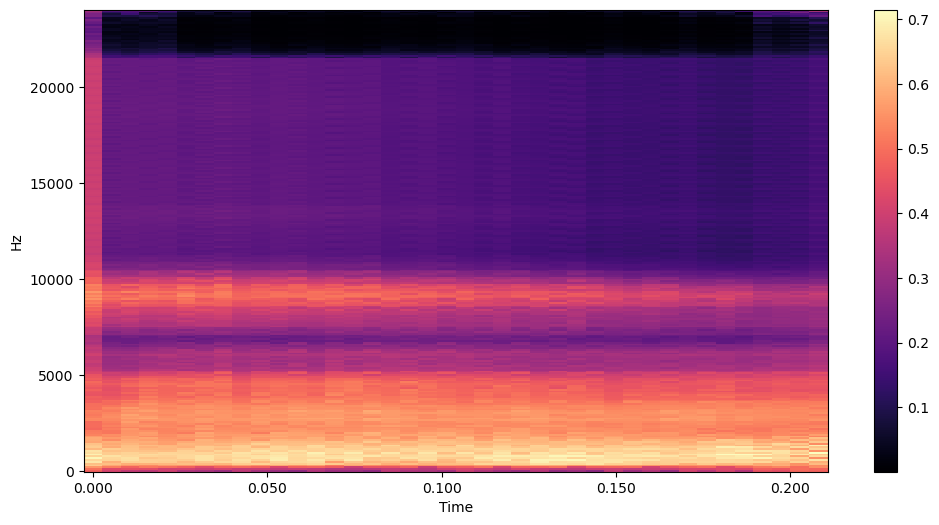

In [18]:
prediction = restored_predictions[0]
plot_spectrogram(prediction, SR, HOP_LENGTH)